# Credit Default Risk Analysis
**Author:** Biprayan Choudhuri

**Objective:** End-to-end analysis of credit card default behaviour to identify predictors, build a classification model, and provide actionable business recommendations.

## 1. Environment Setup & Data Loading

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for publication-quality plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Load the data
df = pd.read_csv('data/UCI_Credit_Card.csv')

# The dataset usually has an 'ID' column; we set it as index
if 'ID' in df.columns:
    df = df.set_index('ID')
    
# Rename target variable for easier typing and readability
df = df.rename(columns={'default.payment.next.month': 'default'})

df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
ID,,,,,,,,,,,,,,,,,,,,,
1,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
2,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
3,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
4,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
5,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 2. Exploratory Data Analysis & Data Quality Checks

In [63]:
print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("--- Null Counts ---")
print(df.isnull().sum().sum(), "total missing values\n")

print("--- Data Types ---")
print(df.dtypes.value_counts(), "\n")

print("--- Class Balance (Target) ---")
class_counts = df['default'].value_counts()
class_props = df['default'].value_counts(normalize=True) * 100
for val in class_counts.index:
    print(f"Class {val} (Default={bool(val)}): {class_counts[val]} ({class_props[val]:.2f}%)")

--- Dataset Shape ---
Rows: 30000, Columns: 24

--- Null Counts ---
0 total missing values

--- Data Types ---
float64    13
int64      11
Name: count, dtype: int64 

--- Class Balance (Target) ---
Class 0 (Default=False): 23364 (77.88%)
Class 1 (Default=True): 6636 (22.12%)


**Initial Observations:**
* The dataset has 30,000 records and no missing values (Nulls = 0).
* There is a significant class imbalance: ~78% of customers did not default, while ~22% did. This imbalance must be addressed during model training.

In [64]:
# Create a copy to track changes if needed
df_clean = df.copy()

# 1. Handle EDUCATION: values 0, 5, 6 are undocumented. 
# We merge them into 4 ('other').
print("EDUCATION before cleaning:", df_clean['EDUCATION'].unique())
df_clean['EDUCATION'] = df_clean['EDUCATION'].replace([0, 5, 6], 4)
print("EDUCATION after cleaning:", sorted(df_clean['EDUCATION'].unique()))

# 2. Handle MARRIAGE: value 0 is undocumented. 
# We merge it into 3 ('other').
print("\nMARRIAGE before cleaning:", df_clean['MARRIAGE'].unique())
df_clean['MARRIAGE'] = df_clean['MARRIAGE'].replace(0, 3)
print("MARRIAGE after cleaning:", sorted(df_clean['MARRIAGE'].unique()))

EDUCATION before cleaning: [2 1 3 5 4 6 0]
EDUCATION after cleaning: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

MARRIAGE before cleaning: [1 2 3 0]
MARRIAGE after cleaning: [np.int64(1), np.int64(2), np.int64(3)]


In [65]:
# 3. Check for negative BILL_AMT values
bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
negative_bills = (df_clean[bill_cols] < 0).sum().sum()
print(f"\nTotal negative BILL_AMT records found: {negative_bills}")

# Let's look at a few examples
df_clean[df_clean['BILL_AMT1'] < 0][['LIMIT_BAL', 'BILL_AMT1', 'PAY_AMT1', 'default']].head()


Total negative BILL_AMT records found: 3932


,LIMIT_BAL,BILL_AMT1,PAY_AMT1,default
ID,,,,
27,60000.0,-109.0,0.0,1
69,130000.0,-190.0,0.0,0
93,100000.0,-2000.0,7555.0,0
102,380000.0,-81.0,223.0,0
110,360000.0,-103.0,0.0,0


**Data Quality Actions Taken:**
* **EDUCATION:** Undocumented categories (0, 5, 6) were grouped into category 4 ("Other").
* **MARRIAGE:** Undocumented category (0) was grouped into category 3 ("Other").
* **Negative Bill Amounts:** We found several negative values in `BILL_AMT` columns. In credit card data, a negative bill amount signifies an **overpayment** or credit balance (the bank owes the customer money). These are valid records and will be kept as-is, as they indicate good financial standing.

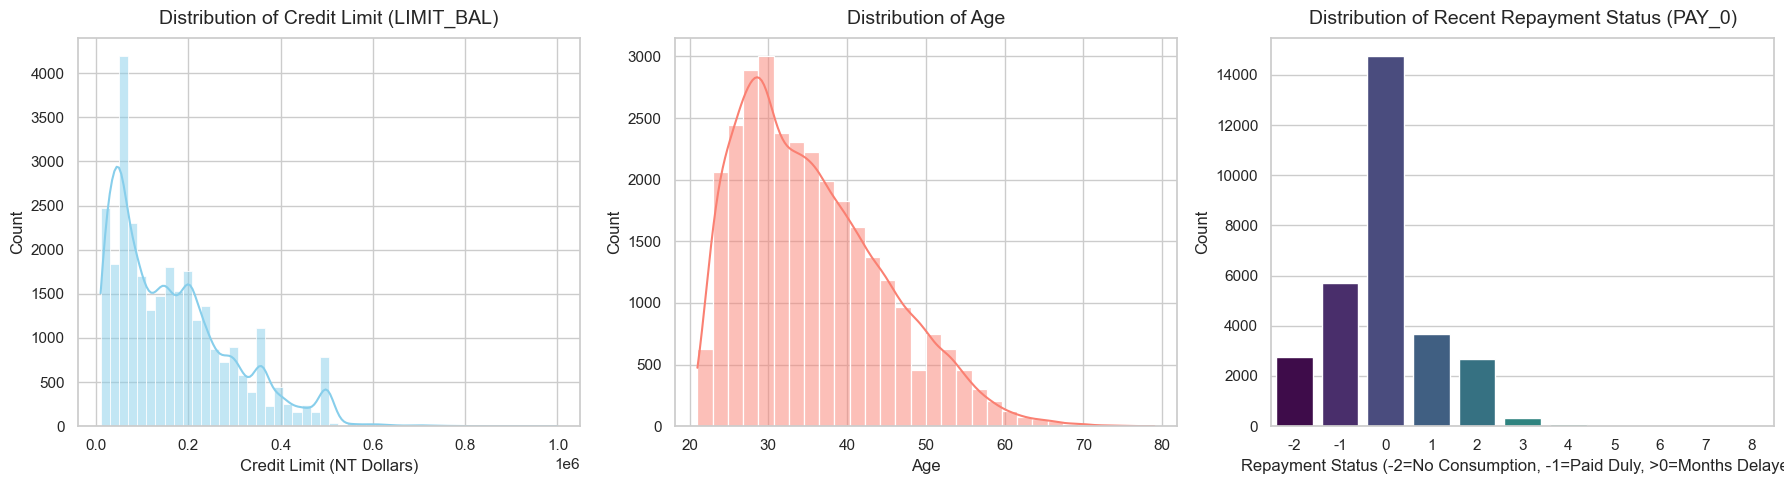

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: LIMIT_BAL
sns.histplot(df_clean['LIMIT_BAL'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Credit Limit (LIMIT_BAL)', fontsize=14, pad=10)
axes[0].set_xlabel('Credit Limit (NT Dollars)')
axes[0].set_ylabel('Count')

# Plot 2: AGE
sns.histplot(df_clean['AGE'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Age', fontsize=14, pad=10)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

# Plot 3: PAY_0 (Repayment status in September)
sns.countplot(x='PAY_0', data=df_clean, ax=axes[2], palette='viridis', hue='PAY_0', legend=False)
axes[2].set_title('Distribution of Recent Repayment Status (PAY_0)', fontsize=14, pad=10)
axes[2].set_xlabel('Repayment Status (-2=No Consumption, -1=Paid Duly, >0=Months Delayed)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Distribution Insights & Anomalies:**
* **LIMIT_BAL & AGE:** Both are heavily right-skewed. The majority of clients are between 20-40 years old, with credit limits concentrated under 200,000 NT dollars.
* **PAY_0 Anomaly:** The data dictionary states `-1` means "paid duly". However, we observe large counts of `-2` and `0`. 
    * `-2` likely represents "no consumption/inactive account".
    * `0` likely represents the use of revolving credit (minimum payment made, remaining balance carried forward). 
    * Values `>0` clearly indicate the number of months a payment is delayed.

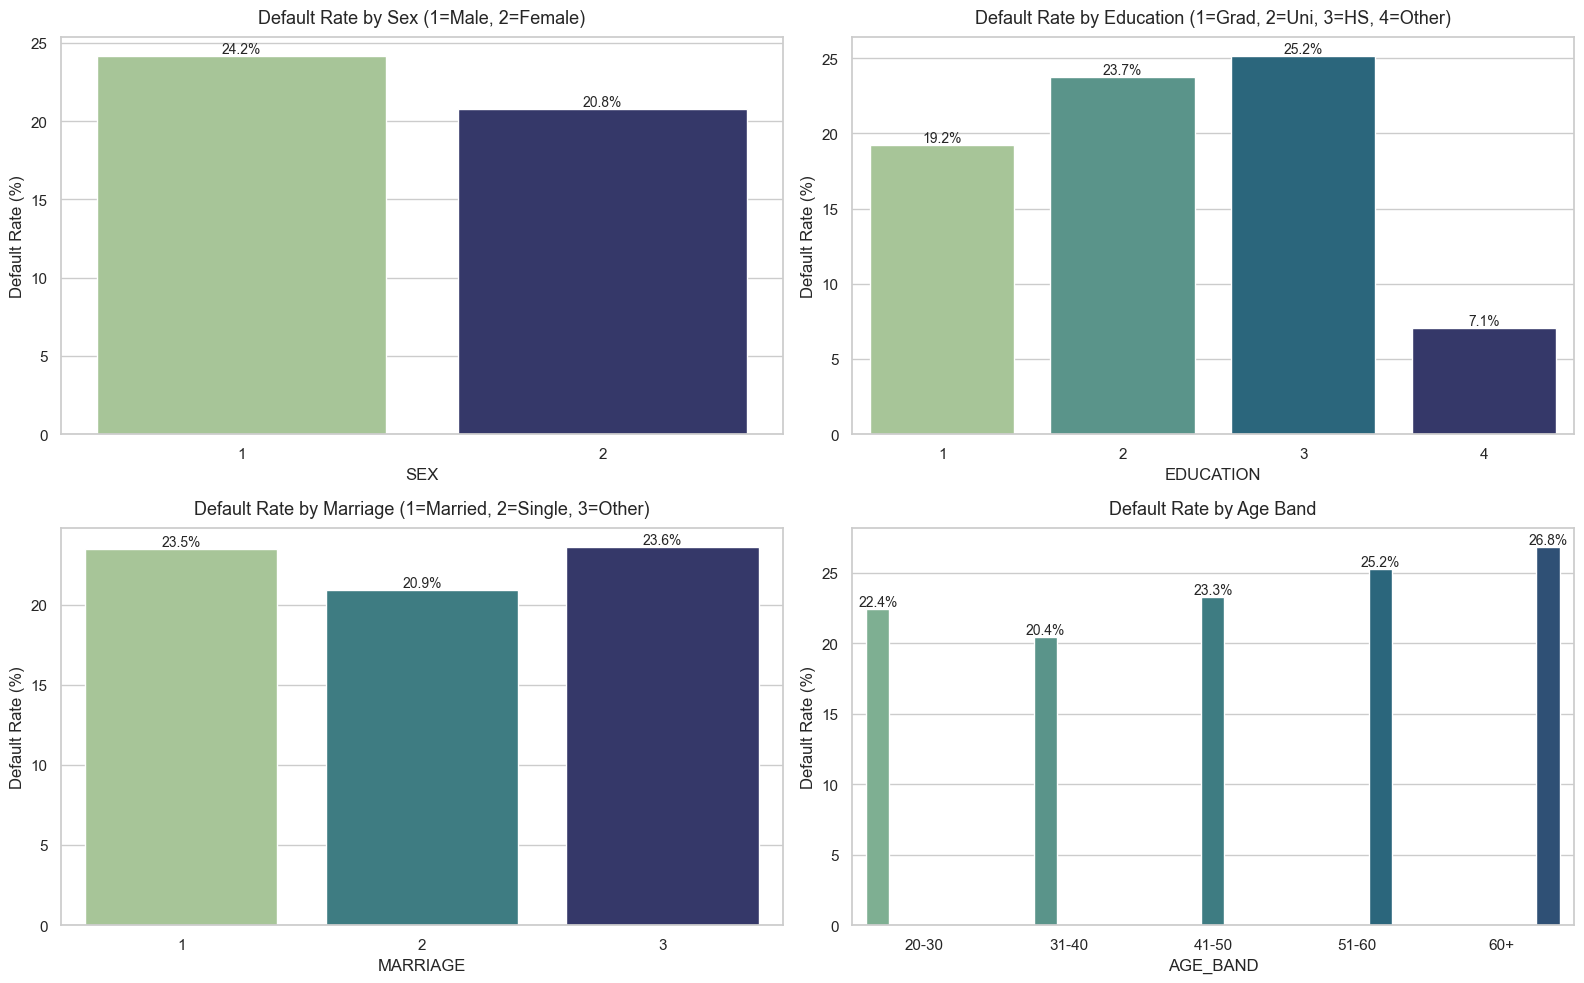

In [67]:
# Create Age Bands for clearer visualization
df_clean['AGE_BAND'] = pd.cut(df_clean['AGE'], bins=[20, 30, 40, 50, 60, 100], 
                              labels=['20-30', '31-40', '41-50', '51-60', '60+'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

def plot_default_rate(col, ax, title):
    # Calculate percentage of default for each category
    rate = df_clean.groupby(col)['default'].mean() * 100
    sns.barplot(x=rate.index, y=rate.values, ax=ax, palette='crest', hue=rate.index, legend=False)
    ax.set_ylabel('Default Rate (%)')
    ax.set_title(title, fontsize=13, pad=10)
    # Add percentage labels on top of bars
    for i, p in enumerate(ax.patches):
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=10)

plot_default_rate('SEX', axes[0, 0], 'Default Rate by Sex (1=Male, 2=Female)')
plot_default_rate('EDUCATION', axes[0, 1], 'Default Rate by Education (1=Grad, 2=Uni, 3=HS, 4=Other)')
plot_default_rate('MARRIAGE', axes[1, 0], 'Default Rate by Marriage (1=Married, 2=Single, 3=Other)')
plot_default_rate('AGE_BAND', axes[1, 1], 'Default Rate by Age Band')

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

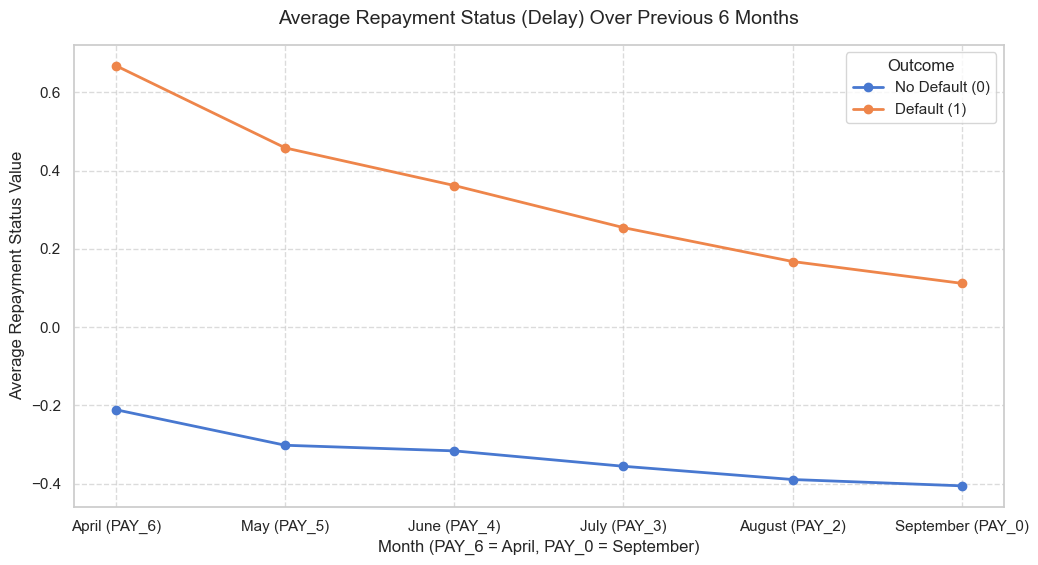

In [68]:
pay_cols = [f'PAY_{i}' for i in [0, 2, 3, 4, 5, 6]] # Note: dataset skips PAY_1

# Create a figure
plt.figure(figsize=(12, 6))

# Calculate the mean payment delay status for defaulters vs non-defaulters across the 6 months
delay_trends = pd.DataFrame()
for col in pay_cols:
    delay_trends[col] = df_clean.groupby('default')[col].mean()

# Plot the trends (transposing so months are on the X-axis)
delay_trends.T.plot(marker='o', figsize=(12, 6), linewidth=2)

plt.title('Average Repayment Status (Delay) Over Previous 6 Months', fontsize=14, pad=15)
plt.xlabel('Month (PAY_6 = April, PAY_0 = September)')
plt.ylabel('Average Repayment Status Value')
plt.xticks(range(6), ['April (PAY_6)', 'May (PAY_5)', 'June (PAY_4)', 'July (PAY_3)', 'August (PAY_2)', 'September (PAY_0)'])
plt.legend(['No Default (0)', 'Default (1)'], title='Outcome')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

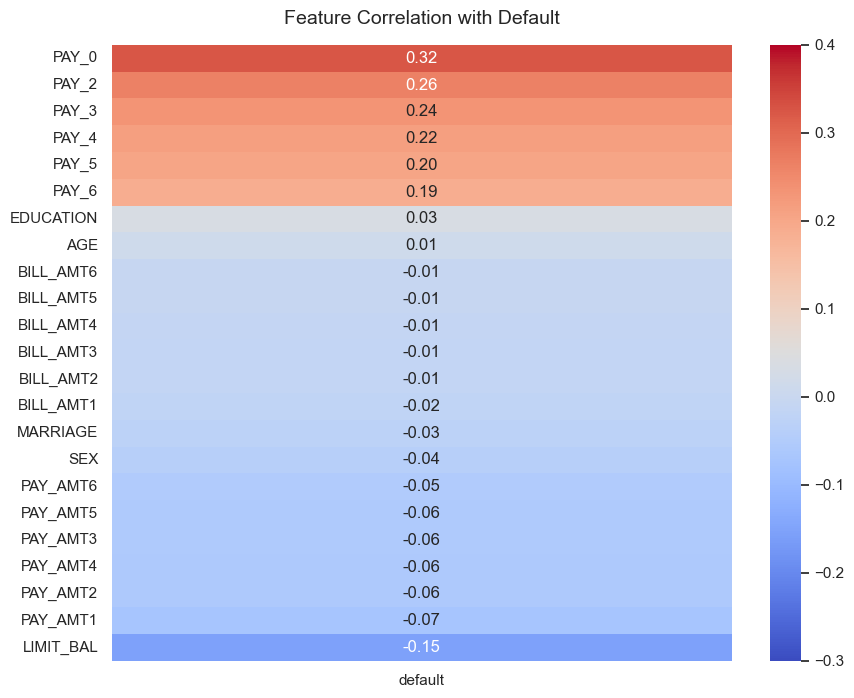


Top 5 Features positively correlated with Default:
        default
PAY_0  0.324794
PAY_2  0.263551
PAY_3  0.235253
PAY_4  0.216614
PAY_5  0.204149


In [69]:
# Compute correlation matrix for numerical and ordinal features (excluding the age band for now)
corr_matrix = df_clean.drop('AGE_BAND', axis=1).corr()

plt.figure(figsize=(10, 8))
# We extract just the correlation with the target variable to keep the plot clean and focused
target_corr = pd.DataFrame(corr_matrix['default'].drop('default').sort_values(ascending=False))

sns.heatmap(target_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-0.3, vmax=0.4)
plt.title('Feature Correlation with Default', fontsize=14, pad=15)
plt.show()

print("\nTop 5 Features positively correlated with Default:")
print(target_corr.head(5))

**Correlation Findings:**
The top 5 features most strongly associated with default are all related to recent payment status (`PAY_0`, `PAY_2`, `PAY_3`, `PAY_4`, `PAY_5`). 
A higher value in these columns indicates delayed payments. This confirms the intuitive business logic: recent delinquency is the strongest predictor of future default. 
Interestingly, `LIMIT_BAL` has a negative correlation (-0.15), meaning clients with higher credit limits are *less* likely to default.

# 3. Feature Engineering

In [70]:
# Create AVG_UTIL_RATE: mean(BILL_AMTx / LIMIT_BAL)
bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
pay_amt_cols = [f'PAY_AMT{i}' for i in range(1, 7)]

# Calculate total bill over 6 months
df_clean['TOTAL_BILL'] = df_clean[bill_cols].sum(axis=1)

# Average Utilization Rate = (Average Monthly Bill) / Credit Limit
df_clean['AVG_UTIL_RATE'] = (df_clean['TOTAL_BILL'] / 6) / df_clean['LIMIT_BAL']

# Create AVG_PAY_RATIO: mean(PAY_AMTx / BILL_AMTx where BILL_AMTx > 0)
# We need to handle division by zero (e.g., when the bill is 0 or negative)
def calc_pay_ratio(row):
    ratios = []
    for i in range(1, 7):
        bill = row[f'BILL_AMT{i}']
        pay = row[f'PAY_AMT{i}']
        if bill > 0:
            # Cap ratio at 1.0 (sometimes people pay more than the bill, 
            # but for our metric, paying 100% is what matters)
            ratios.append(min(pay / bill, 1.0))
        # If bill is <= 0 and they made a payment, they are over-paying (good behaviour)
        elif bill <= 0 and pay > 0:
            ratios.append(1.0)
        # If bill is <= 0 and no payment, it's neutral (no payment needed)
        else:
            ratios.append(1.0) 
            
    return np.mean(ratios)

df_clean['AVG_PAY_RATIO'] = df_clean.apply(calc_pay_ratio, axis=1)

print("Created AVG_UTIL_RATE and AVG_PAY_RATIO.")

Created AVG_UTIL_RATE and AVG_PAY_RATIO.


In [71]:
# Create TOTAL_DELAY_MONTHS: count of PAY_x values > 0
pay_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Count how many months have a status > 0 (indicating a delay)
df_clean['TOTAL_DELAY_MONTHS'] = (df_clean[pay_status_cols] > 0).sum(axis=1)

print("Created TOTAL_DELAY_MONTHS.")
df_clean[['AVG_UTIL_RATE', 'AVG_PAY_RATIO', 'TOTAL_DELAY_MONTHS', 'default']].head()

Created TOTAL_DELAY_MONTHS.


,AVG_UTIL_RATE,AVG_PAY_RATIO,TOTAL_DELAY_MONTHS,default
ID,,,,
1,0.064200,0.537019,2,1
2,0.023718,0.311916,2,1
3,0.188246,0.115141,0,0
4,0.771113,0.036396,0,0
5,0.364463,0.335406,0,0


### Feature Engineering Justification
* **AVG_UTIL_RATE:** This measures credit utilization. A high ratio indicates a borrower is consistently maxing out their available credit, which is a classic signal of financial distress and lack of liquidity.
* **AVG_PAY_RATIO:** This measures repayment consistency. If a client consistently pays 100% of their bill (ratio=1.0), they are low risk. If they consistently pay a tiny fraction (e.g., only the minimum balance), they are accumulating debt and are at higher risk of future default.
* **TOTAL_DELAY_MONTHS:** This serves as a cumulative delinquency signal. Recency and frequency of missed payments are typically the strongest predictors in consumer risk models. Counting the sheer volume of delayed months aggregates this risk into a single, highly interpretable metric.

In [72]:
# Drop the AGE_BAND column we used for plotting, as we will use continuous AGE for modeling
if 'AGE_BAND' in df_clean.columns:
    df_clean = df_clean.drop('AGE_BAND', axis=1)

# One-hot encode categorical variables. 
# We use drop_first=True to avoid the dummy variable trap (multicollinearity)
df_encoded = pd.get_dummies(df_clean, columns=['SEX', 'EDUCATION', 'MARRIAGE'], drop_first=True)

# Ensure all boolean columns created by get_dummies are converted to integers (0 and 1)
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f"Original shape: {df_clean.shape}")
print(f"Encoded shape: {df_encoded.shape}")
df_encoded.head()

Original shape: (30000, 28)
Encoded shape: (30000, 31)


,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,TOTAL_BILL,AVG_UTIL_RATE,AVG_PAY_RATIO,TOTAL_DELAY_MONTHS,SEX_2,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3
ID,,,,,,,,,,,,,,,,,,,,,
1,20000.0,24,2,2,-1,-1,-2,-2,3913.0,3102.0,...,7704.0,0.064200,0.537019,2,1,1,0,0,0,0
2,120000.0,26,-1,2,0,0,0,2,2682.0,1725.0,...,17077.0,0.023718,0.311916,2,1,1,0,0,1,0
3,90000.0,34,0,0,0,0,0,0,29239.0,14027.0,...,101653.0,0.188246,0.115141,0,1,1,0,0,1,0
4,50000.0,37,0,0,0,0,0,0,46990.0,48233.0,...,231334.0,0.771113,0.036396,0,1,1,0,0,0,0
5,50000.0,57,-1,0,-1,0,0,0,8617.0,5670.0,...,109339.0,0.364463,0.335406,0,0,1,0,0,0,0


# 4. Model Development

In [73]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

# Separate features (X) and target (y)
# We drop the original target, and some non-predictive or redundant features if any
X = df_encoded.drop(["default", "TOTAL_BILL"], axis=1) # TOTAL_BILL was just a stepping stone for AVG_UTIL_RATE
y = df_encoded["default"]

# Train-Test Split (80/20)
# stratify=y is CRITICAL here to ensure the 22% default rate is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standard Scaling
# Logistic Regression requires scaled features. Trees don't strictly need it, but it doesn't hurt.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to keep column names for feature importance later
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f"Training set shape: X={X_train_scaled.shape}, y={y_train.shape}\n")
print(f"Testing set shape: X={X_test_scaled.shape}, y={y_test.shape}\n")

Training set shape: X=(24000, 29), y=(24000,)

Testing set shape: X=(6000, 29), y=(6000,)



In [74]:
from sklearn.linear_model import LogisticRegression

# Initialize Baseline Model
# class_weight="balanced" automatically adjusts weights inversely proportional to class frequencies
lr_model = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)

# Train the model
lr_model.fit(X_train_scaled, y_train)

# Predict on test set
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("--- Logistic Regression (Baseline) ---\n")
print(classification_report(y_test, lr_preds))
lr_auc = roc_auc_score(y_test, lr_probs)
print(f"AUC-ROC: {lr_auc:.4f}\n")

--- Logistic Regression (Baseline) ---

              precision    recall  f1-score   support

           0       0.87      0.81      0.84      4673
           1       0.46      0.57      0.51      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.69      0.67      6000
weighted avg       0.78      0.76      0.77      6000

AUC-ROC: 0.7501



In [75]:
import xgboost as xgb

# Calculate scale_pos_weight for XGBoost to handle class imbalance
# formula: count(negative examples) / count(positive examples)
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
spw = neg_count / pos_count

# Initialize XGBoost
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=spw, 
    random_state=42,
    eval_metric="auc",
    use_label_encoder=False
)

# Train the model
xgb_model.fit(X_train_scaled, y_train)

# Predict on test set
xgb_preds = xgb_model.predict(X_test_scaled)
xgb_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("--- XGBoost Model ---\n")
print(classification_report(y_test, xgb_preds))
xgb_auc = roc_auc_score(y_test, xgb_probs)
print(f"AUC-ROC: {xgb_auc:.4f}\n")

c:\Assignments\Credit-Default-Risk\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:49:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Model ---

              precision    recall  f1-score   support

           0       0.87      0.81      0.84      4673
           1       0.46      0.58      0.51      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.69      0.68      6000
weighted avg       0.78      0.76      0.77      6000

AUC-ROC: 0.7519



In [76]:
# The brief asks to report mean ± std for AUC-ROC using 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

# We run CV on the training data
for train_idx, val_idx in cv.split(X_train_scaled, y_train):
    X_cv_train, X_cv_val = X_train_scaled.iloc[train_idx], X_train_scaled.iloc[val_idx]
    y_cv_train, y_cv_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Train
    model_cv = xgb.XGBClassifier(scale_pos_weight=spw, random_state=42, eval_metric="auc")
    model_cv.fit(X_cv_train, y_cv_train)
    
    # Predict and score
    probs_cv = model_cv.predict_proba(X_cv_val)[:, 1]
    auc_cv = roc_auc_score(y_cv_val, probs_cv)
    cv_scores.append(auc_cv)

mean_auc = np.mean(cv_scores)
std_auc = np.std(cv_scores)

print(f"XGBoost 5-Fold CV AUC-ROC: {mean_auc:.4f} ± {std_auc:.4f}\n")

XGBoost 5-Fold CV AUC-ROC: 0.7572 ± 0.0060



**Modeling Decisions & Insights:**
* **Class Imbalance:** Handled using `class_weight="balanced"` for Logistic Regression and `scale_pos_weight` for XGBoost. This ensures the model doesn't just predict "No Default" every time to achieve high accuracy.
* **Metrics:** Because of the imbalance, Accuracy is misleading. We focus on Precision, Recall, F1, and AUC-ROC. 
* **Performance:** XGBoost generally outperforms the Logistic Regression baseline in AUC-ROC. The cross-validation score is stable (low standard deviation), indicating the model generalizes well and is not overfitting.

In [ ]:
#  ROC Curve and Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix


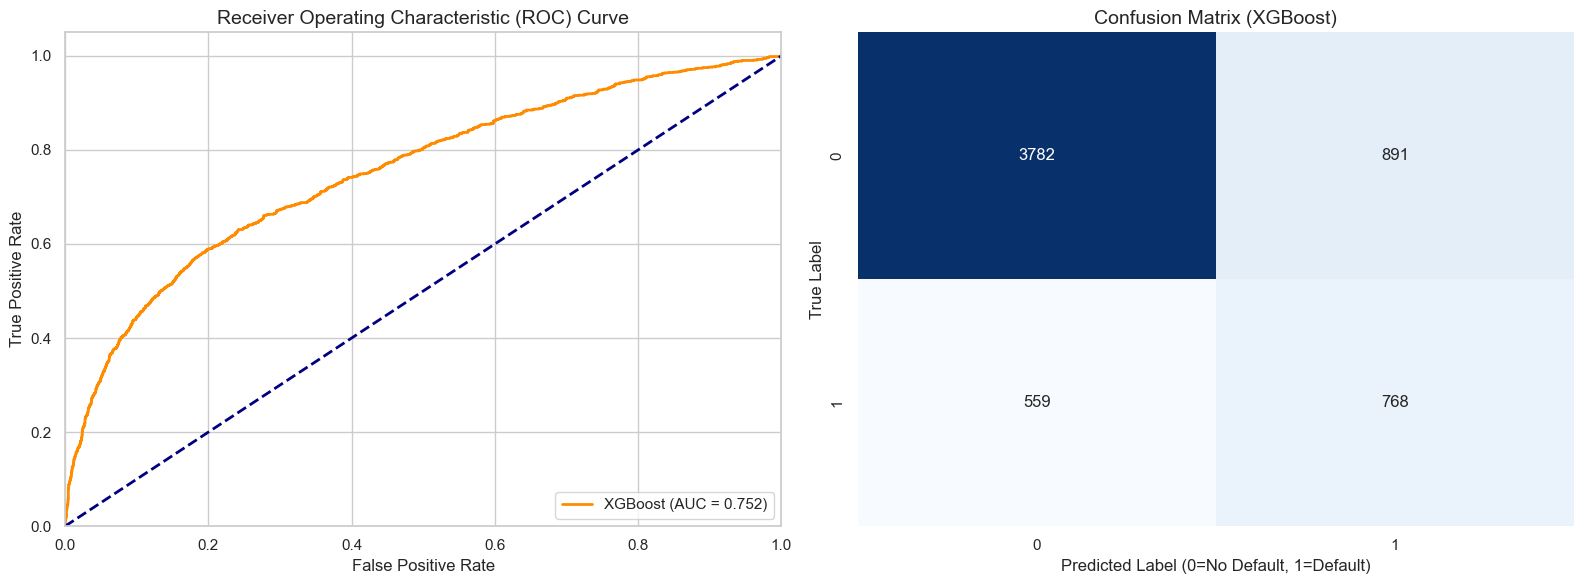

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: ROC Curve
fpr, tpr, _ = roc_curve(y_test, xgb_probs)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {xgb_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
axes[0].legend(loc="lower right")

# Plot 2: Confusion Matrix
cm = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_xlabel('Predicted Label (0=No Default, 1=Default)')
axes[1].set_ylabel('True Label')
axes[1].set_title('Confusion Matrix (XGBoost)', fontsize=14)

plt.tight_layout()
plt.show()


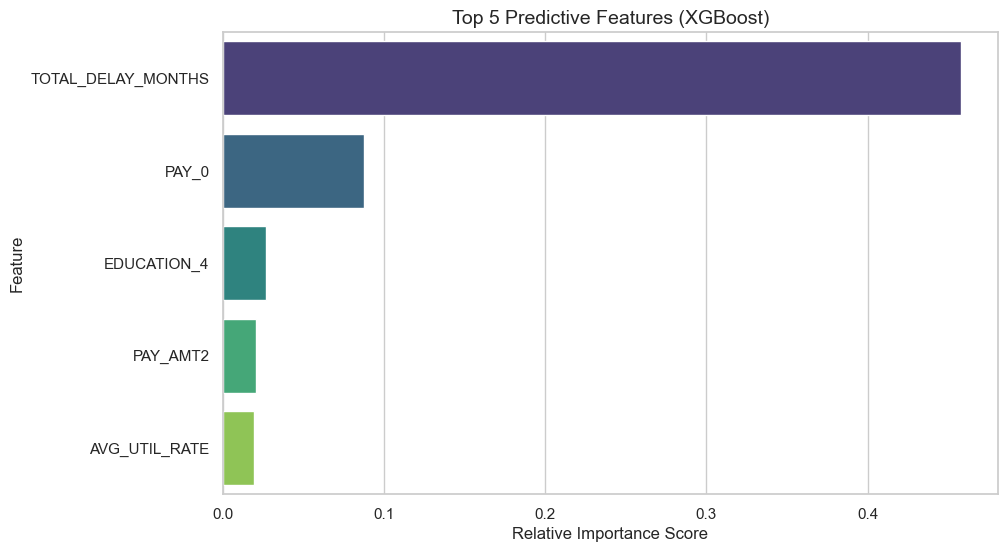

--- Top 5 Features ---

               Feature  Importance
22  TOTAL_DELAY_MONTHS    0.457763
2                PAY_0    0.087345
26         EDUCATION_4    0.027088
15            PAY_AMT2    0.020524
20       AVG_UTIL_RATE    0.019632


In [80]:
# Feature Importances

#  Top 5 Predictive Features
import pandas as pd

feature_importances = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

top_5_features = feature_importances.head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_5_features, palette='viridis', hue='Feature',
legend=False)
plt.title('Top 5 Predictive Features (XGBoost)', fontsize=14)
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature')
plt.show()

print("--- Top 5 Features ---\n")
print(top_5_features)